Выгружаем данные

In [ ]:
import os
import numpy as np
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()
DATABASE_URL = os.getenv("DATABASE_URL")
engine = create_engine(DATABASE_URL)

sql = """
    select
        user_id,
        CASE
            WHEN preferred_variant = 'A' THEN 0
            WHEN preferred_variant = 'B' THEN 1
        END as choose
    from db1.public.feedback_preferences
    ORDER BY 1, 2
"""
df = pd.read_sql_query(sql, con=engine)

df.head()

,user_id,choose
0,00887a81-b943-49fd-a07b-8fcb09337dac,0
1,00887a81-b943-49fd-a07b-8fcb09337dac,1
2,00887a81-b943-49fd-a07b-8fcb09337dac,0
3,00887a81-b943-49fd-a07b-8fcb09337dac,0
4,00887a81-b943-49fd-a07b-8fcb09337dac,1


Считаем результаты

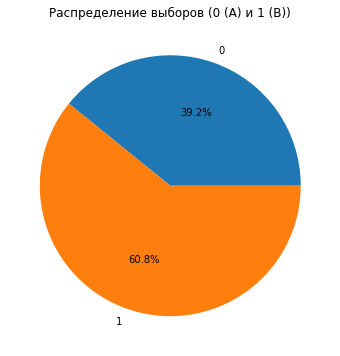

In [50]:
import matplotlib.pyplot as plt

# Подсчёт распределения
counts = df["choose"].value_counts().sort_index()

# Подписи
labels = ["0", "1"]

# Построение pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title("Распределение выборов (0 (A) и 1 (B))")
plt.show()

In [51]:
df["choose"].value_counts()

choose
1    73
0    47
Name: count, dtype: int64

In [ ]:
import statsmodels.api as sm

df["intercept"] = 1

model = sm.GEE.from_formula(
    "choose ~ 1",
    groups="user_id",
    data=df,
    family=sm.families.Binomial()
)

result = model.fit()

summary = result.summary().as_text()

lines = [
    line for line in summary.split("\n")
    if not line.startswith("Date:") and not line.startswith("Time:")
]

clean_summary = "\n".join(lines)

print(clean_summary)

                               GEE Regression Results                              
Dep. Variable:                      choose   No. Observations:                  120
Model:                                 GEE   No. clusters:                       40
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                   6
Family:                           Binomial   Mean cluster size:                 3.0
Dependence structure:         Independence   Num. iterations:                     2
Date:                     Sun, 10 May 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         17:38:59
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4403      0.204      2.162      0.031       0.041       0.839
Skew:  

In [48]:
import numpy as np

beta = 0.4403

p = 1 / (1 + np.exp(-beta))

lower = 0.041
upper = 0.839

p_lower = 1 / (1 + np.exp(-lower))
p_upper = 1 / (1 + np.exp(-upper))

print(f"{p} : [{p_lower}, {p_upper}]")

0.6083305124190959 : [0.5102485643871594, 0.6982545626546939]
